<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/deciontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import files
file=files.upload()

Saving large_classification_dataset.csv to large_classification_dataset.csv


In [3]:
df=pd.read_csv(list(file.keys())[0])

In [4]:
df

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,72230,6,99,85,Pass,Pass
1,53592,5,87,68,Fail,Pass
2,21912,9,79,65,Fail,Pass
3,76933,8,41,52,Fail,Pass
4,13964,1,80,56,Fail,Fail
...,...,...,...,...,...,...
9995,24953,7,45,64,Fail,Pass
9996,17567,3,86,42,Fail,Pass
9997,89369,4,69,73,Fail,Pass
9998,70860,6,78,39,Fail,Pass


In [5]:
df.head()

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,72230,6,99,85,Pass,Pass
1,53592,5,87,68,Fail,Pass
2,21912,9,79,65,Fail,Pass
3,76933,8,41,52,Fail,Pass
4,13964,1,80,56,Fail,Fail


In [6]:
df.isnull().sum()

,0
Student_ID,0
Hours_Studied,0
Attendance,0
Assignment_Score,0
Previous_Result,0
Final_Result,0


In [7]:
# Get the name of the last column
last_column_name = df.columns[-1]

# Drop the last column and store the result in x
x = df.drop(columns=[last_column_name])

# Display the first few rows of the new DataFrame x to verify
display(x.head())

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result
0,72230,6,99,85,Pass
1,53592,5,87,68,Fail
2,21912,9,79,65,Fail
3,76933,8,41,52,Fail
4,13964,1,80,56,Fail


In [8]:
y = df[[last_column_name]]
display(y.head())

,Final_Result
0,Pass
1,Pass
2,Pass
3,Pass
4,Fail


In [9]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler

# Convert categorical variables to dummy/indicator variables
xtrain_encoded = pd.get_dummies(xtrain)
xtest_encoded = pd.get_dummies(xtest)

# Ensure both train and test have the same columns after encoding
xtrain_encoded, xtest_encoded = xtrain_encoded.align(xtest_encoded, join='left', axis=1, fill_value=0)

sc = StandardScaler()
xtrain = sc.fit_transform(xtrain_encoded)
xtest = sc.transform(xtest_encoded)

In [11]:
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier(criterion='entropy', random_state=0)

In [12]:
classifier.fit(xtrain, ytrain)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [13]:
ypred=classifier.predict(xtest)

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
cm=confusion_matrix(ytest, ypred)
print('Confusion Matrix:\n', cm)
print('Accuracy:', accuracy_score(ytest, ypred))
print('Precision:', precision_score(ytest, ypred, pos_label='Pass'))
print('Recall:', recall_score(ytest, ypred, pos_label='Pass'))
print('F1 Score:', f1_score(ytest, ypred, pos_label='Pass'))

Confusion Matrix:
 [[ 171   17]
 [  14 1798]]
Accuracy: 0.9845
Precision: 0.990633608815427
Recall: 0.9922737306843267
F1 Score: 0.9914529914529915


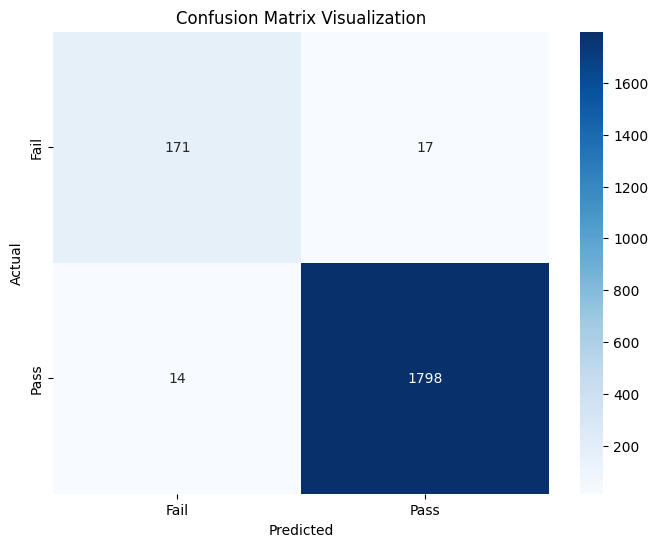

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualizer(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix Visualization')
    plt.show()

visualizer(cm)